In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage.metrics import structural_similarity as ssim
from scipy import ndimage
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

In [ ]:
classes = ['Bacterial Pneumonia', 'Corona Virus Disease',
           'Normal', 'Tuberculosis', 'Viral Pneumonia']

class_to_label = {cls:i for i, cls in enumerate(classes)}

In [ ]:
def preprocess_image(path):
    img = cv2.imread(path, 0)
    img = cv2.equalizeHist(img)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.stack([img]*3, axis=-1)
    return img

In [ ]:
def extract_features(image):
    gray = cv2.cvtColor((image*255).astype('uint8'), cv2.COLOR_BGR2GRAY)

    # Normalize image to float32
    gray = gray.astype(np.float32) / 255.0

    # HOG Features
    hog_feat = hog(gray, pixels_per_cell=(16,16), cells_per_block=(2,2))

    # Sobel gradients (SAFE)
    sobelx = ndimage.sobel(gray, axis=0)
    sobely = ndimage.sobel(gray, axis=1)

    grad_mag = np.sqrt(sobelx**2 + sobely**2)

    # 🔥 Clip to avoid overflow
    grad_mag = np.clip(grad_mag, 0, 10)

    grad_var = np.var(grad_mag)

    # Ratios
    black_ratio = np.sum(gray < 0.2) / gray.size
    white_ratio = np.sum(gray > 0.8) / gray.size

    features = np.hstack([hog_feat, grad_var, black_ratio, white_ratio])

    # 🔥 FINAL SAFETY CHECK
    features = np.nan_to_num(features, nan=0.0, posinf=1.0, neginf=0.0)

    return features

In [ ]:
from sklearn.preprocessing import StandardScaler

def train_kmeans_sample(data_dir, classes, sample_size=500):

    paths = []
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        for file in os.listdir(cls_path):
            paths.append(os.path.join(cls_path, file))

    np.random.shuffle(paths)
    paths = paths[:sample_size]

    features = []

    for path in paths:
        img = preprocess_image(path)
        feat = extract_features(img)
        features.append(feat)

    features = np.array(features)

    # 🔥 SCALE FEATURES (VERY IMPORTANT)
    scaler = StandardScaler()
    features = scaler.fit_transform(features)

    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(features)

    return kmeans, scaler

In [ ]:
kmeans = train_kmeans_sample("/content/drive/MyDrive/Lung Disease Dataset/train", classes, 500)

In [ ]:
def enhance(img):
    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
    return cv2.filter2D(img, -1, kernel)

def reconstruct(img):
    return cv2.GaussianBlur(img, (3,3), 0)

In [ ]:
import math

class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, data_dir, classes, kmeans, scaler, batch_size=16):
        self.paths = []
        self.labels = []
        self.batch_size = batch_size
        self.kmeans = kmeans
        self.scaler = scaler

        for cls in classes:
            cls_path = os.path.join(data_dir, cls)
            for file in os.listdir(cls_path):
                self.paths.append(os.path.join(cls_path, file))
                self.labels.append(classes.index(cls))

    def __len__(self):
        # Return the number of batches in the dataset
        return math.ceil(len(self.paths) / self.batch_size)

    @property
    def num_batches(self):
        # Explicitly implement num_batches as requested by the error message
        return self.__len__()

    def __getitem__(self, idx):
        batch_paths = self.paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        images = []

        for path in batch_paths:
            img = preprocess_image(path)

            feat = extract_features(img).reshape(1, -1)
            feat = self.scaler.transform(feat)   # 🔥 IMPORTANT

            cluster = self.kmeans.predict(feat)[0]

            if cluster == 1:
                img = enhance(img)

            images.append(img)

        return np.array(images), tf.keras.utils.to_categorical(batch_labels, 5)

In [ ]:
train_dir = "/content/drive/MyDrive/Lung Disease Dataset/train"
val_dir   = "/content/drive/MyDrive/Lung Disease Dataset/val"
test_dir  = "/content/drive/MyDrive/Lung Disease Dataset/test"

In [ ]:
kmeans, scaler = train_kmeans_sample(train_dir, classes, 500)

train_gen = DataGenerator(train_dir, classes, kmeans, scaler)
val_gen   = DataGenerator(val_dir, classes, kmeans, scaler)
test_gen  = DataGenerator(test_dir, classes, kmeans, scaler)

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.layers import Dense, Reshape, multiply, Conv2D, Concatenate, Lambda

def cbam_block(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    # ===== Channel Attention =====
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalMaxPooling2D()(input_feature)

    shared = Dense(channel // ratio, activation='relu')

    avg_out = shared(avg_pool)
    max_out = shared(max_pool)

    channel_attention = Dense(channel, activation='sigmoid')(avg_out + max_out)
    channel_attention = Reshape((1,1,channel))(channel_attention)

    x = multiply([input_feature, channel_attention])

    # ===== Spatial Attention (FIXED) =====
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)

    x = multiply([x, spatial_attention])

    return x

In [ ]:
input_img = Input(shape=(224,224,3))

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_img)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = cbam_block(x)
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_img, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/tmp/ipykernel_1466/332497707.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_img)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,327,560 (12.69 MB)

 Trainable params: 1,069,576 (4.08 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4856 - loss: 1.3267

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


379/379 ━━━━━━━━━━━━━━━━━━━━ 1595s 4s/step - accuracy: 0.6100 - loss: 0.9396 - val_accuracy: 0.7101 - val_loss: 0.6104
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 371s 978ms/step - accuracy: 0.7718 - loss: 0.5378 - val_accuracy: 0.7773 - val_loss: 0.5191
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 313s 825ms/step - accuracy: 0.7893 - loss: 0.4916 - val_accuracy: 0.7911 - val_loss: 0.4951
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 315s 832ms/step - accuracy: 0.8156 - loss: 0.4374 - val_accuracy: 0.8207 - val_loss: 0.4308
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 311s 821ms/step - accuracy: 0.8298 - loss: 0.4065 - val_accuracy: 0.8296 - val_loss: 0.4307
Epoch 6/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 315s 831ms/step - accuracy: 0.8385 - loss: 0.3885 - val_accuracy: 0.7931 - val_loss: 0.5274
Epoch 7/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 304s 801ms/step - accuracy: 0.8519 - loss: 0.3569 - val_accuracy: 0.7857 - val_loss: 0.5100
Epoch 8/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 318s 839ms/step - accuracy: 0.8437 - loss: 0.3653

In [ ]:
model.evaluate(test_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


127/127 ━━━━━━━━━━━━━━━━━━━━ 668s 5s/step - accuracy: 0.8642 - loss: 0.3688


[0.3687543570995331, 0.8641975522041321]

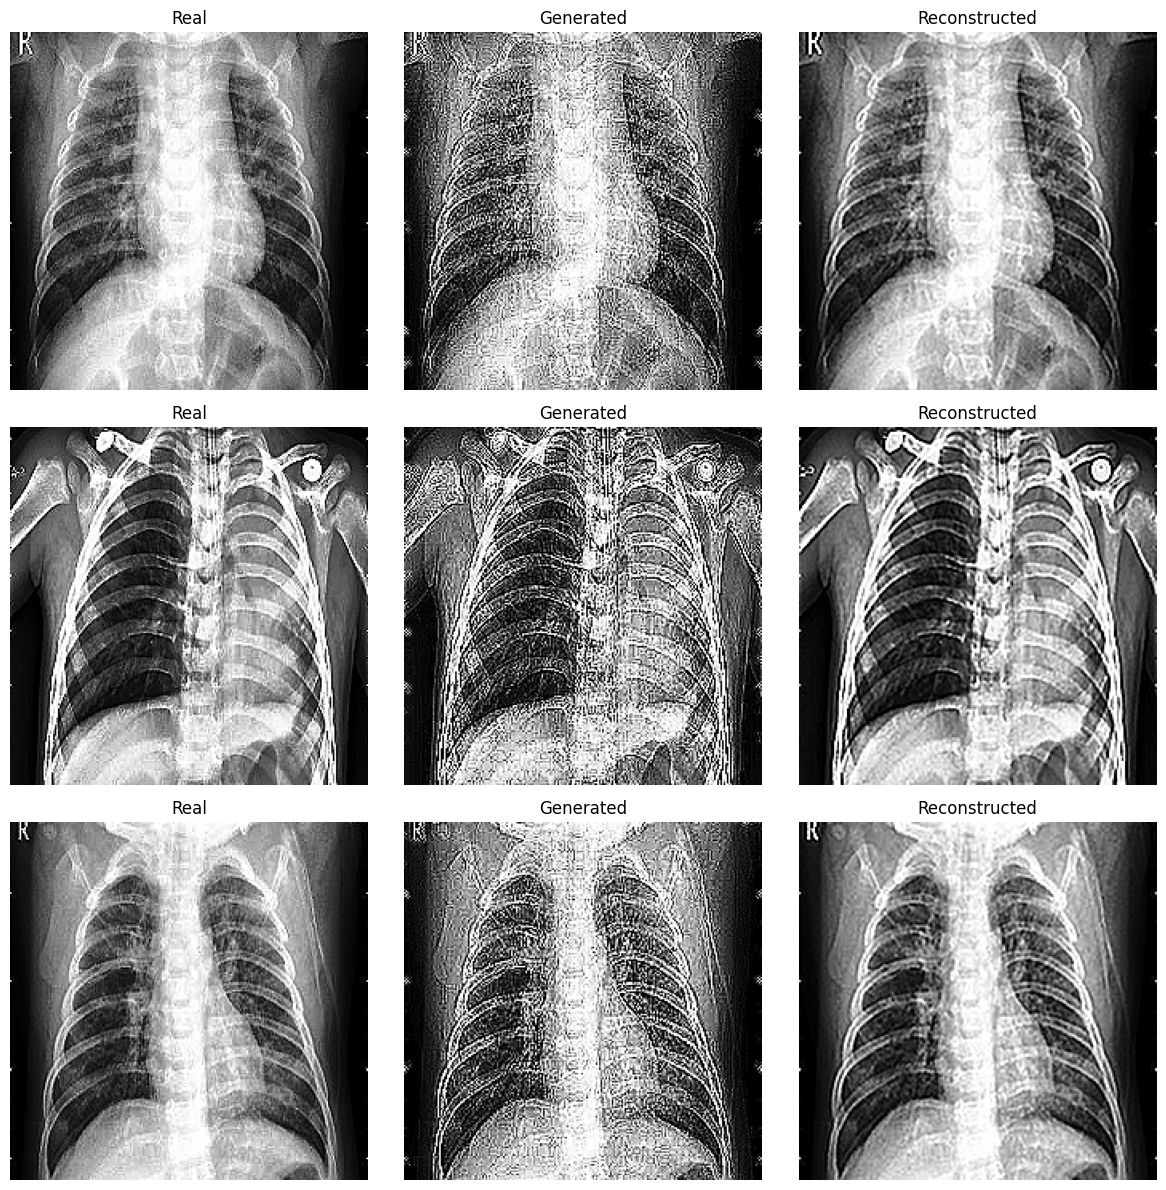

In [ ]:
def show_fig8(generator, n=3):
    batch_x, _ = generator[0]

    plt.figure(figsize=(12, 4*n))

    for i in range(n):
        real = batch_x[i]
        gen = enhance(real)
        rec = reconstruct(gen)

        plt.subplot(n,3,3*i+1)
        plt.imshow(real)
        plt.title("Real")
        plt.axis('off')

        plt.subplot(n,3,3*i+2)
        plt.imshow(gen)
        plt.title("Generated")
        plt.axis('off')

        plt.subplot(n,3,3*i+3)
        plt.imshow(rec)
        plt.title("Reconstructed")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_fig8(test_gen)

In [ ]:
from skimage.metrics import structural_similarity as ssim

def compute_ssim(generator, n=5):
    batch_x, _ = generator[0]

    for i in range(n):
        real = batch_x[i]
        gen = enhance(real)
        rec = reconstruct(gen)

        score = ssim(real, rec, channel_axis=2, data_range=1.0)  # ✅ FIX
        print(f"Image {i} SSIM: {score:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels from the test generator
y_true = []
for i in range(len(test_gen)):
    _, labels = test_gen[i]
    y_true.extend(np.argmax(labels, axis=1))

# Get predictions from the model on the test generator
y_pred_raw = model.predict(test_gen)
y_pred = np.argmax(y_pred_raw, axis=1)

# Generate and print the classification report
report = classification_report(y_true, y_pred, target_names=classes)
print(report)

127/127 ━━━━━━━━━━━━━━━━━━━━ 86s 667ms/step
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.73      0.83      0.78       403
Corona Virus Disease       0.94      0.97      0.95       407
              Normal       0.89      0.94      0.91       404
        Tuberculosis       0.98      0.95      0.97       408
     Viral Pneumonia       0.79      0.63      0.70       403

            accuracy                           0.86      2025
           macro avg       0.86      0.86      0.86      2025
        weighted avg       0.87      0.86      0.86      2025



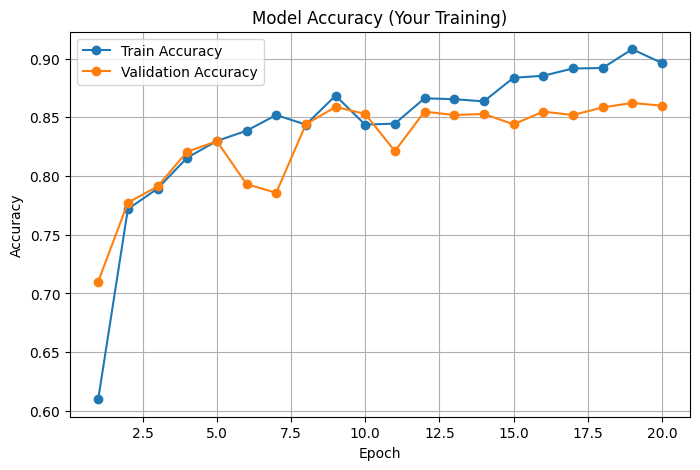

In [ ]:
import matplotlib.pyplot as plt

# Your values from training logs
train_acc = [
    0.6100, 0.7718, 0.7893, 0.8156, 0.8298,
    0.8385, 0.8519, 0.8437, 0.8684, 0.8437,
    0.8446, 0.8661, 0.8654, 0.8635, 0.8836,
    0.8853, 0.8915, 0.8919, 0.9079, 0.8962
]

val_acc = [
    0.7101, 0.7773, 0.7911, 0.8207, 0.8296,
    0.7931, 0.7857, 0.8440, 0.8588, 0.8528,
    0.8212, 0.8548, 0.8519, 0.8528, 0.8440,
    0.8548, 0.8519, 0.8583, 0.8622, 0.8598
]

epochs = range(1, 21)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.title('Model Accuracy (Your Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

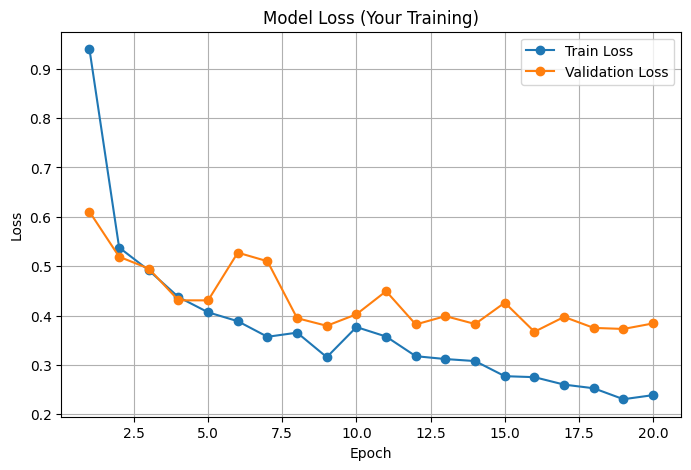

In [ ]:
train_loss = [
    0.9396, 0.5378, 0.4916, 0.4374, 0.4065,
    0.3885, 0.3569, 0.3653, 0.3156, 0.3766,
    0.3574, 0.3176, 0.3118, 0.3077, 0.2771,
    0.2751, 0.2600, 0.2526, 0.2304, 0.2387
]

val_loss = [
    0.6104, 0.5191, 0.4951, 0.4308, 0.4307,
    0.5274, 0.5100, 0.3946, 0.3792, 0.4025,
    0.4493, 0.3819, 0.3988, 0.3828, 0.4260,
    0.3671, 0.3972, 0.3749, 0.3728, 0.3840
]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.title('Model Loss (Your Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

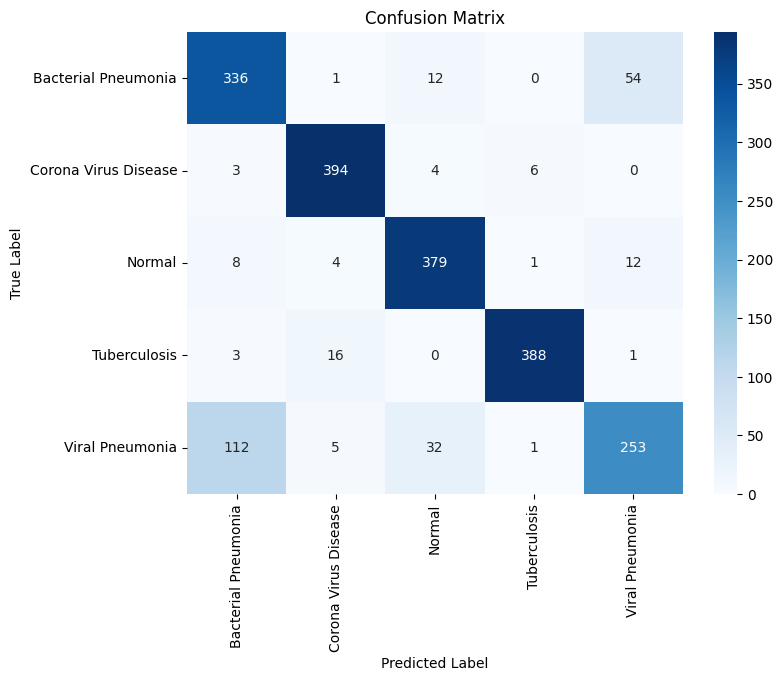

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save("lung_model.h5")

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional optimization (recommended)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("lung_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved!")

Saved artifact at '/tmp/tmpa0db_61b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134369788685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788686032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788687184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788687376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788689488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788689104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788686992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13436978868564

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpjb_pikrj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134369788685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788686032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788687184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788688912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788687376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788689488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788689104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134369788686992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13436978868564

In [ ]:
interpreter = tf.lite.Interpreter(model_path="lung_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 204, 'shape': array([1, 5], dtype=int32), 'shape_signature': array([-1,  5], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
last_conv_layer_name = "Conv_1"

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def prepare_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    return np.expand_dims(img, axis=0), img

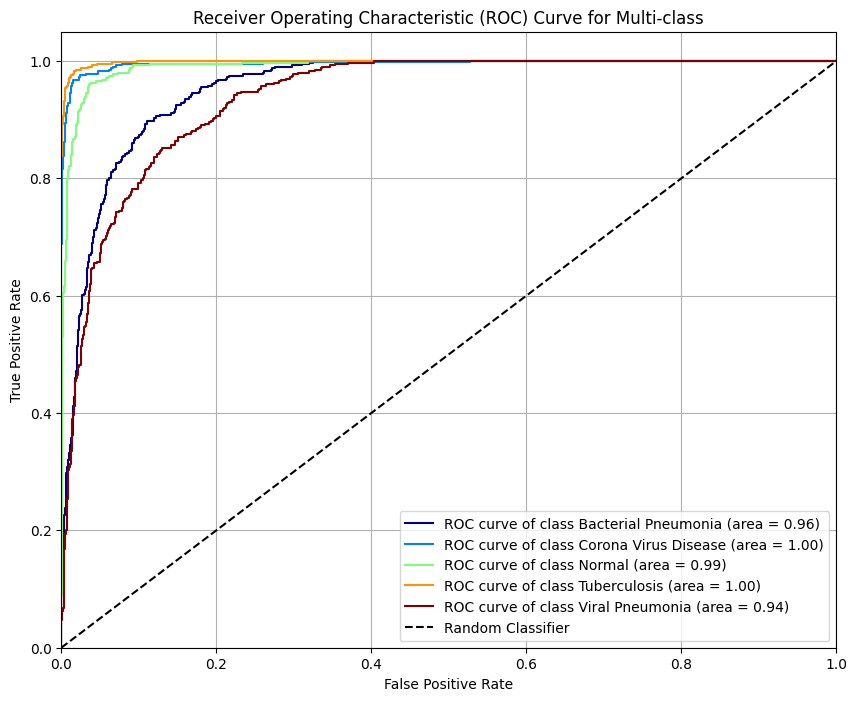

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Convert y_true to a binarized format for multi-class ROC
# Assuming y_true is a list of integer labels and classes is defined
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(y_true)

# Number of classes
n_classes = len(classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_raw[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
# FIX: Get an iterable of colors from the colormap
cmap = plt.colormaps.get_cmap('jet') # Use the recommended way to get cmap
colors = [cmap(i) for i in np.linspace(0, 1, n_classes)] # Generate N distinct colors
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
def predict_image_class(image_path):
    # Preprocess the image
    img = preprocess_image(image_path)

    # Extract features
    feat = extract_features(img).reshape(1, -1)
    feat = scaler.transform(feat)  # Apply the same scaler used during training

    # Predict cluster for enhancement decision
    cluster = kmeans.predict(feat)[0]

    if cluster == 1:
        img = enhance(img)

    # Prepare image for model prediction (add batch dimension)
    img_for_prediction = np.expand_dims(img, axis=0)

    # Get raw predictions (probabilities)
    predictions = model.predict(img_for_prediction)
    predicted_probabilities = predictions[0]

    # Get the predicted class index
    predicted_class_idx = np.argmax(predicted_probabilities)

    # Get the predicted class name
    predicted_class_name = classes[predicted_class_idx]

    return predicted_class_name, predicted_probabilities

# Example usage:
example_image_path = "/content/drive/MyDrive/Lung Disease Dataset/test/Corona Virus Disease/00030364_000.png"
predicted_class, probabilities = predict_image_class(example_image_path)

print(f"Image: {example_image_path}")
print(f"Predicted Class: {predicted_class}")
print("Class Probabilities:")
for i, prob in enumerate(probabilities):
    print(f"  {classes[i]}: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image: /content/drive/MyDrive/Lung Disease Dataset/test/Corona Virus Disease/00030364_000.png
Predicted Class: Corona Virus Disease
Class Probabilities:
  Bacterial Pneumonia: 0.0000
  Corona Virus Disease: 1.0000
  Normal: 0.0000
  Tuberculosis: 0.0000
  Viral Pneumonia: 0.0000
